# JCP Fall 26 Week 3: EDA, Visualizations & Models

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")   # colorblind-friendly by default for the whole notebook
plt.rcParams["figure.figsize"] = (7, 4)
np.random.seed(0)   # makes the random jitter below the same every run

In [87]:
DATA_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/"

taxis = pd.read_csv(DATA_URL + "taxis.csv")   # demo

# We read the raw CSV (instead of sns.load_dataset) so nothing gets pre-cleaned for us.

In [88]:
# Your turn: create a DataFrame named 'cars' the same way we loaded 'taxis'. The CSV is "mpg.csv".
cars = pd.read_csv(DATA_URL + "mpg.csv")

---
## Part 1: EDA

### 1A. First look

In [89]:
taxis.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [90]:
taxis.shape

(6433, 14)

In [91]:
taxis.dtypes   # look at pickup / dropoff — remember this for 1C

pickup              object
dropoff             object
passengers           int64
distance           float64
fare               float64
tip                float64
tolls              float64
total              float64
color               object
payment             object
pickup_zone         object
dropoff_zone        object
pickup_borough      object
dropoff_borough     object
dtype: object

In [92]:
taxis.nunique()   # few unique values → probably categorical (color, payment). Many → numeric.

pickup             6414
dropoff            6425
passengers            7
distance           1079
fare                220
tip                 489
tolls                16
total               898
color                 2
payment               2
pickup_zone         194
dropoff_zone        203
pickup_borough        4
dropoff_borough       5
dtype: int64

### 1B. Missing values

In [93]:
taxis.isna().head()   # what will this output?

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [94]:
taxis.isna().sum()   # what will this output?

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [95]:
taxis.isna().mean().round(4)  # will this output a table, series, or single value?

pickup             0.0000
dropoff            0.0000
passengers         0.0000
distance           0.0000
fare               0.0000
tip                0.0000
tolls              0.0000
total              0.0000
color              0.0000
payment            0.0068
pickup_zone        0.0040
dropoff_zone       0.0070
pickup_borough     0.0040
dropoff_borough    0.0070
dtype: float64

Everything is under 5%, so dropping looks safe. But first — is missingness related to what we care about (fare)?

In [96]:
borough_missing = taxis["pickup_borough"].isna()
borough_missing.value_counts()

pickup_borough
False    6407
True       26
Name: count, dtype: int64

In [97]:
taxis.groupby(borough_missing)["fare"].mean()   # False = borough known, True = borough missing

pickup_borough
False    13.039156
True     25.884615
Name: fare, dtype: float64

Rides with no pickup borough cost about **2×** as much. Dropping them would quietly remove the expensive rides.

In [98]:
taxis_dropped = taxis.dropna()
print(taxis.shape, "->", taxis_dropped.shape)

(6433, 14) -> (6341, 14)


In [99]:
print("mean fare, all rows:    ", round(taxis["fare"].mean(), 2))
print("mean fare, after dropna:", round(taxis_dropped["fare"].mean(), 2))

mean fare, all rows:     13.09
mean fare, after dropna: 12.89


For categorical columns, a safe imputation is an explicit `"Unknown"` category — no rows lost, and a model can still learn that "unknown" rides are different.

In [100]:
cat_cols = ["payment", "pickup_zone", "dropoff_zone", "pickup_borough", "dropoff_borough"]
taxis[cat_cols] = taxis[cat_cols].fillna("Unknown")   # reassign! fillna doesn't change taxis in place

In [101]:
taxis.isna().sum().sum()   # 0 missing, and we still have every row

np.int64(0)

### Your Turn
`cars` has missing values in `horsepower`.
1. Is missingness related to `mpg`? Compare mean `mpg` for rows with vs. without a missing `horsepower`.
2. Build `cars_dropped` (rows missing `horsepower` removed) and `cars_imputed` (missing `horsepower` filled with the column mean).

In [102]:
hp_missing = cars["horsepower"].isna()
cars.groupby(hp_missing)["mpg"].mean()   # False = horsepower known, True = horsepower missing

horsepower
False    23.445918
True     28.000000
Name: mpg, dtype: float64

In [103]:
cars_dropped = cars.dropna(subset=["horsepower"])
cars_imputed = cars.copy()
cars_imputed["horsepower"] = cars_imputed["horsepower"].fillna(cars["horsepower"].mean())
print(len(cars), "->", len(cars_dropped), "dropped |", len(cars_imputed), "imputed")

398 -> 392 dropped | 398 imputed


In [104]:
# Only ~1.5% missing → we'll drop. Everything below uses this version of cars.
cars = cars_dropped.reset_index(drop=True)

In [105]:
# Check: run me
assert len(cars_imputed) == 398 and cars_imputed["horsepower"].isna().sum() == 0, "cars_imputed should keep all 398 rows with no missing horsepower"
assert len(cars) == 392 and cars.isna().sum().sum() == 0, "cars should have 392 rows and nothing missing"
print("Check passed")

Check passed


### 1C. Temporality

In [106]:
taxis["pickup"].head()   # looks like dates...

0    2019-03-23 20:21:09
1    2019-03-04 16:11:55
2    2019-03-27 17:53:01
3    2019-03-10 01:23:59
4    2019-03-30 13:27:42
Name: pickup, dtype: object

In [107]:
type(taxis["pickup"].iloc[0])   # ...but each one is just a string

str

In [108]:
taxis["pickup"] = pd.to_datetime(taxis["pickup"])
taxis["dropoff"] = pd.to_datetime(taxis["dropoff"])
taxis[["pickup", "dropoff"]].dtypes

pickup     datetime64[ns]
dropoff    datetime64[ns]
dtype: object

In [109]:
taxis["pickup"].dt.hour.head()

0    20
1    16
2    17
3     1
4    13
Name: pickup, dtype: int32

In [110]:
taxis["pickup"].dt.day_name().head()

0     Saturday
1       Monday
2    Wednesday
3       Sunday
4     Saturday
Name: pickup, dtype: object

In [111]:
taxis["hour"] = taxis["pickup"].dt.hour
taxis["day_name"] = taxis["pickup"].dt.day_name()

In [112]:
taxis["pickup"].min(), taxis["pickup"].max()   # one month of data... plus a straggler? (see 1E)

(Timestamp('2019-02-28 23:29:03'), Timestamp('2019-03-31 23:43:45'))

In [113]:
trip_time = taxis["dropoff"] - taxis["pickup"]   # datetime - datetime = Timedelta
trip_time.head()

0   0 days 00:06:15
1   0 days 00:07:05
2   0 days 00:07:24
3   0 days 00:25:52
4   0 days 00:09:32
dtype: timedelta64[ns]

In [114]:
taxis["duration_min"] = trip_time.dt.total_seconds() / 60
taxis["duration_min"].describe()

count    6433.000000
mean       14.349617
std        11.643892
min         0.000000
25%         6.500000
50%        10.900000
75%        18.516667
max       107.666667
Name: duration_min, dtype: float64

### Your Turn
`model_year` stores `70`, `71`, … as integers. Convert it to a datetime column called `year`. `pd.to_datetime` needs strings plus a `format=` here — `"%y"` means two-digit year.

In [115]:
cars["year"] = pd.to_datetime(cars["model_year"].astype(str), format="%y")
cars[["model_year", "year"]].head()

,model_year,year
0,70,1970-01-01
1,70,1970-01-01
2,70,1970-01-01
3,70,1970-01-01
4,70,1970-01-01


In [116]:
# Check: run me
assert str(cars["year"].dtype).startswith("datetime64"), "year should be a datetime column"
assert cars["year"].dt.year.min() == 1970 and cars["year"].dt.year.max() == 1982, "years should run 1970–1982"
print("Check passed")

Check passed


### 1D. Granularity & Scope

In [117]:
taxis["pickup_borough"].value_counts(normalize=True).round(3)   # scope: mostly Manhattan

pickup_borough
Manhattan    0.819
Queens       0.102
Brooklyn     0.060
Bronx        0.015
Unknown      0.004
Name: proportion, dtype: float64

In [118]:
# If our question were only about airport rides, the data is too general → filter to our scope
airport_rides = taxis[taxis["pickup_zone"].str.contains("Airport") | taxis["dropoff_zone"].str.contains("Airport")]
len(airport_rides)

407

### 1E. Faithfulness

In [119]:
taxis.duplicated().sum()

np.int64(0)

In [120]:
(taxis["passengers"] == 0).sum()   # a 0-passenger ride? probably a default value, not reality

np.int64(96)

In [121]:
(taxis["distance"] == 0).sum()

np.int64(51)

In [122]:
(taxis["duration_min"] <= 0).sum()

np.int64(6)

In [123]:
(taxis["pickup"].dt.month != 3).sum()   # the straggler from 1C

np.int64(1)

In [124]:
pd.crosstab(taxis["payment"], taxis["tip"] > 0)

tip,False,True
payment,,
Unknown,44,0
cash,1812,0
credit card,455,4122


Cash rides **never** have a tip. People do tip in cash — the meter just doesn't record it. That's a collection-method problem: `tip` is only trustworthy for card rides.

In [125]:
bad_rows = (taxis["distance"] == 0) | (taxis["duration_min"] <= 0) | (taxis["pickup"].dt.month != 3)
taxis_clean = taxis[~bad_rows].copy()   # ~ flips True/False. .copy() → no SettingWithCopyWarning later (Week 2 Kahoot #5)
print(bad_rows.sum(), "bad rows removed →", taxis_clean.shape)

52 bad rows removed → (6381, 17)


### Your Turn
1. Create a `brand` column = the first word of `name` (Week 2 `.str` methods).
2. Look at *every* brand's count and find the typos / two names for the same brand. Fix them with `.replace()`.

In [126]:
cars["brand"] = cars["name"].str.split().str[0]
cars["brand"].value_counts().sort_index()   # sorted alphabetically so near-duplicates sit next to each other

brand
amc              27
audi              7
bmw               2
buick            17
cadillac          2
capri             1
chevroelt         1
chevrolet        43
chevy             3
chrysler          6
datsun           23
dodge            28
fiat              8
ford             48
hi                1
honda            13
maxda             2
mazda            10
mercedes          1
mercedes-benz     2
mercury          11
nissan            1
oldsmobile       10
opel              4
peugeot           8
plymouth         31
pontiac          16
renault           3
saab              4
subaru            4
toyota           25
toyouta           1
triumph           1
vokswagen         1
volkswagen       15
volvo             6
vw                6
Name: count, dtype: int64

In [127]:
brand_fixes = {
    "chevroelt": "chevrolet",   # typo
    "chevy": "chevrolet",       # nickname
    "maxda": "mazda",           # typo
    "toyouta": "toyota",        # typo
    "vokswagen": "volkswagen",  # typo
    "vw": "volkswagen",         # abbreviation
    "mercedes": "mercedes-benz",  # two names for the same brand
}
cars["brand"] = cars["brand"].replace(brand_fixes)
cars["brand"].value_counts().sort_index()

brand
amc              27
audi              7
bmw               2
buick            17
cadillac          2
capri             1
chevrolet        47
chrysler          6
datsun           23
dodge            28
fiat              8
ford             48
hi                1
honda            13
mazda            12
mercedes-benz     3
mercury          11
nissan            1
oldsmobile       10
opel              4
peugeot           8
plymouth         31
pontiac          16
renault           3
saab              4
subaru            4
toyota           26
triumph           1
volkswagen       22
volvo             6
Name: count, dtype: int64

In [128]:
# Check: run me
leftovers = cars["brand"].isin(["chevroelt", "chevy", "maxda", "toyouta", "vokswagen", "vw"])
assert not leftovers.any(), f"still unfixed: {sorted(cars.loc[leftovers, 'brand'].unique())}"
print("Check passed")

Check passed


---
## Part 2: Visualizations
Quick reference versions of each plot type from the slides, on `taxis_clean`. Practice for this part is in the homework.

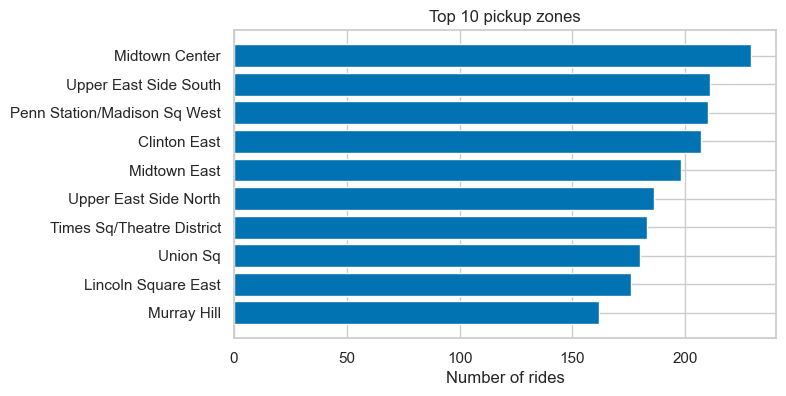

In [129]:
# you can break down multiple commands into multiple lines for a cleaner read
# ^^ you MUST put parentheses around overall statement to do this ^^
# what would top_zones actually return? (BEFORE RUNNING CELL)
top_zones = (
            taxis_clean["pickup_zone"]
            .value_counts()
            .head(10)
            .sort_values()
            )
# barh draws bottom-up → ascending puts the biggest on top
plt.barh(top_zones.index, top_zones.values)
plt.title("Top 10 pickup zones")
plt.xlabel("Number of rides")
plt.show()

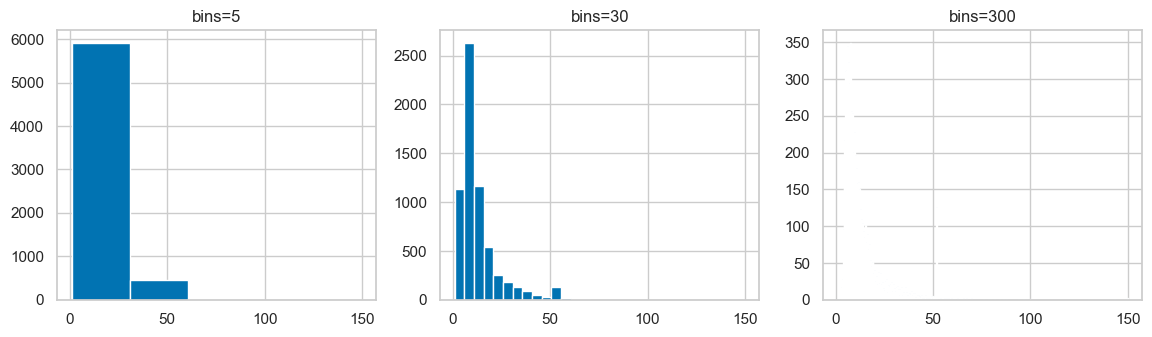

In [130]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))   # same histogram, 3 bin counts
for ax, n_bins in zip(axes, [5, 30, 300]):
    ax.hist(taxis_clean["fare"], bins=n_bins)
    ax.set_title(f"bins={n_bins}")
plt.show()

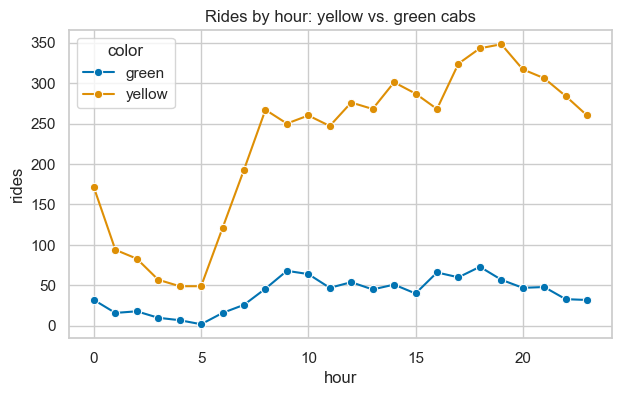

In [131]:
rides_hour_color = (
    taxis_clean
    .groupby(["hour", "color"])
    .size()
    .reset_index(name="rides")
    )
sns.lineplot(data=rides_hour_color, x="hour", y="rides", hue="color", marker="o")
plt.title("Rides by hour: yellow vs. green cabs")
plt.show()

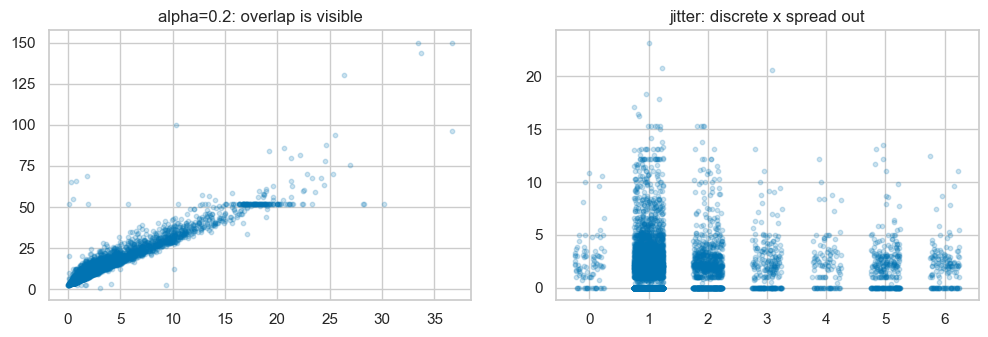

In [132]:
jitter = np.random.uniform(-0.25, 0.25, size=len(taxis_clean))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].scatter(taxis_clean["distance"], taxis_clean["fare"], alpha=0.2, s=10)
axes[0].set_title("alpha=0.2: overlap is visible")
axes[1].scatter(taxis_clean["passengers"] + jitter, taxis_clean["tip"], alpha=0.2, s=10)
axes[1].set_title("jitter: discrete x spread out")
plt.show()

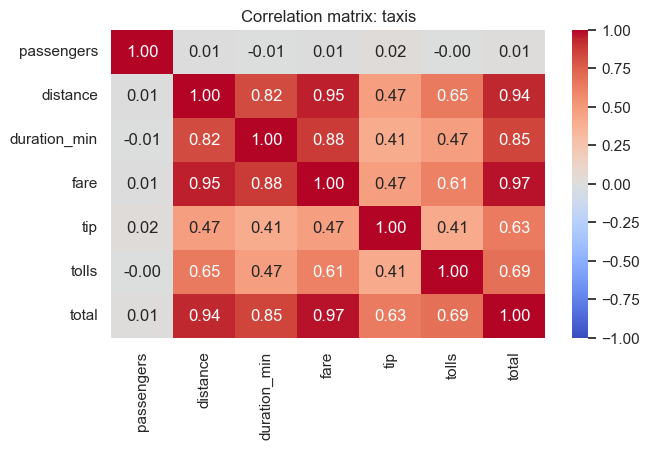

In [133]:
numeric_cols = ["passengers", "distance", "duration_min", "fare", "tip", "tolls", "total"]
sns.heatmap(taxis_clean[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix: taxis")
plt.show()
# fare vs total = 0.97: total literally contains fare → redundant (and cheating if we predict fare)

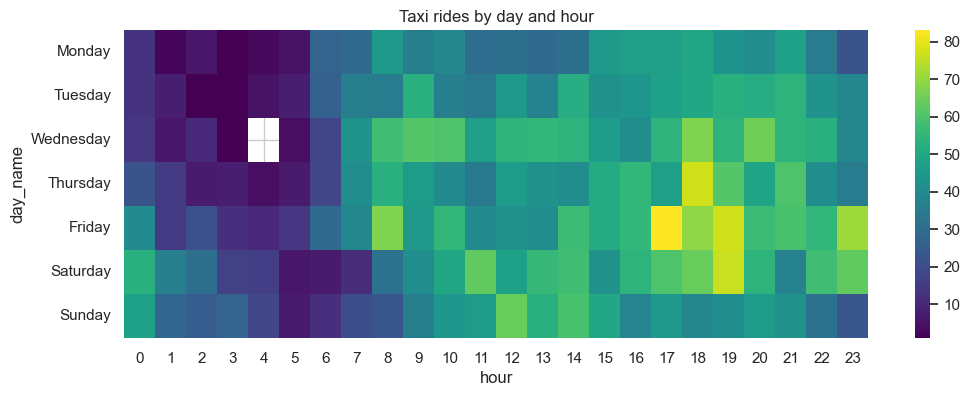

In [134]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
rides_pivot = taxis_clean.pivot_table(index="day_name", columns="hour", values="fare", aggfunc="count").reindex(day_order)
plt.figure(figsize=(12, 4))
sns.heatmap(rides_pivot, cmap="viridis")
plt.title("Taxi rides by day and hour")
plt.show()

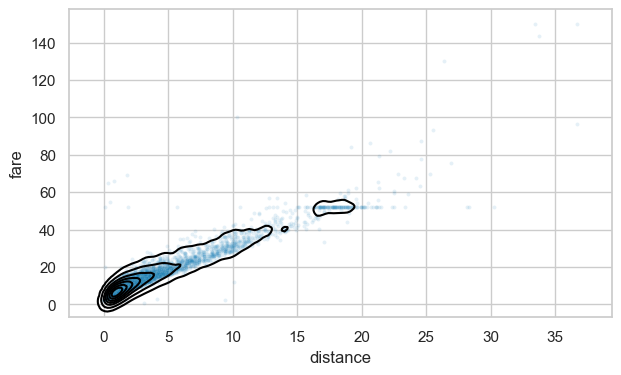

In [135]:
sns.scatterplot(data=taxis_clean, x="distance", y="fare", alpha=0.1, s=8)
sns.kdeplot(data=taxis_clean, x="distance", y="fare", levels=8, color="black")
plt.show()
# density jammed in the corner (fixed by the log below); small island at $52 = NYC's flat JFK fare

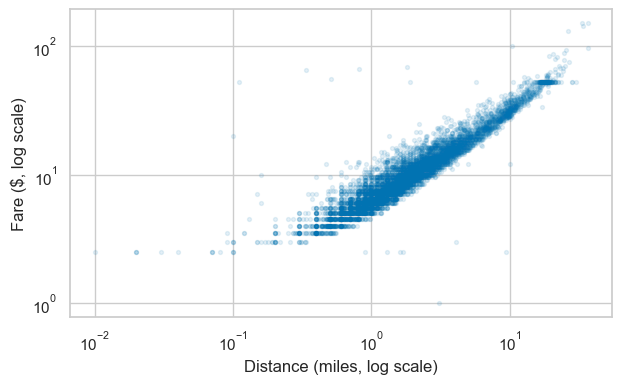

In [136]:
plt.scatter(taxis_clean["distance"], taxis_clean["fare"], alpha=0.1, s=8)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Distance (miles, log scale)")
plt.ylabel("Fare ($, log scale)")
plt.show()

---
## Part 3: Modeling
Goal on the demo side: predict a ride's **`fare`**.

In [137]:
# Load the sklearn tools for this part:
#   train_test_split   -> splits a DataFrame into train and test pieces
#   LinearRegression   -> the linear model (SLR and OLS)
#   mean_squared_error -> scores predictions (lower = better)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

### 3A. Train/test split

In [138]:
# Shuffle the rows, then put 20% in the test set and 80% in the training set.
# random_state=42 makes the shuffle the same every time, so everyone gets the same split.
taxis_train, taxis_test = train_test_split(taxis_clean, test_size=0.2, random_state=42)

# (rows, columns) of each piece
print(taxis_train.shape, taxis_test.shape)

(5104, 17) (1277, 17)


### 3B. Constant model

In [139]:
# "Fitting" the constant model = computing one number from the TRAINING fares: their mean.
theta0 = taxis_train["fare"].mean()
theta0

np.float64(13.106447884012539)

In [140]:
# Predict: make an array that repeats theta0 once per test ride (same guess for every ride)
const_preds = np.full(len(taxis_test), theta0)

# Error for each test ride = actual fare - predicted fare
errors = taxis_test["fare"] - const_preds
errors.head()

1159    -7.106448
5137    19.393552
3031    -9.106448
1330    -6.606448
4979    -3.606448
Name: fare, dtype: float64

In [141]:
# MSE by hand: square each error, then average them
mse_const = np.mean(errors ** 2)

# Same MSE using sklearn's function -> the two numbers should match
print(mse_const, mean_squared_error(taxis_test["fare"], const_preds))

117.53583487694404 117.53583487694404


### 3C. Simple linear regression (SLR)

In [142]:
# Step 1: create an empty model (no parameters yet)
slr = LinearRegression()

# Step 2: fit it on training data -> sklearn finds the best theta0 and theta1
#   X = feature(s): double brackets [[ ]] make a DataFrame (Week 2 Kahoot #1)
#   y = what we're predicting: single brackets -> a Series
slr.fit(taxis_train[["distance"]], taxis_train["fare"])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [143]:
# After fitting, the parameters live on the model:
#   .intercept_ -> theta0 (fare at 0 miles)
#   .coef_      -> array of slopes, one per feature; [0] grabs the only one
print("theta0 (intercept):", round(slr.intercept_, 2))
print("theta1 (per mile): ", round(slr.coef_[0], 2))
# read it as: fare ≈ $theta0 + $theta1 × miles

theta0 (intercept): 4.55
theta1 (per mile):  2.79


In [144]:
# Predict a fare for every TEST ride using its distance
slr_preds = slr.predict(taxis_test[["distance"]])

# Score those predictions and compare to the constant model
mse_slr = mean_squared_error(taxis_test["fare"], slr_preds)
print(f"Constant: {mse_const:.2f} | SLR: {mse_slr:.2f}")

Constant: 117.54 | SLR: 8.83


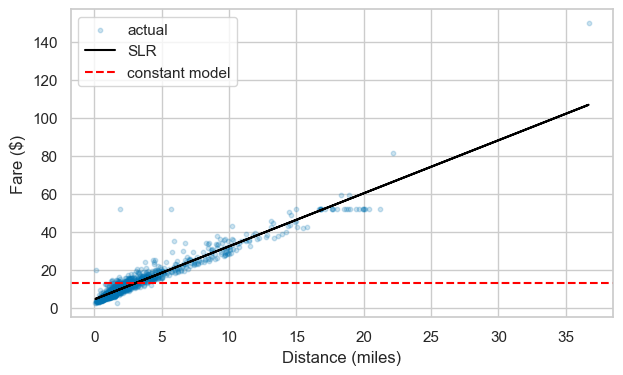

In [145]:
# Actual test fares as dots
plt.scatter(taxis_test["distance"], taxis_test["fare"], alpha=0.2, s=10, label="actual")

# SLR predictions as a line
plt.plot(taxis_test["distance"], slr_preds, color="black", label="SLR")

# Constant model = a flat line at theta0
plt.axhline(theta0, color="red", linestyle="--", label="constant model")

# Labels + legend
plt.xlabel("Distance (miles)")
plt.ylabel("Fare ($)")
plt.legend()
plt.show()

### 3D. OLS (multiple features)

In [146]:
# Same steps as SLR, but X now has two columns
features = ["distance", "duration_min"]
ols = LinearRegression().fit(taxis_train[features], taxis_train["fare"])   # create + fit in one line

# One theta per feature -> label each coefficient with its feature name
pd.Series(ols.coef_, index=features).round(3)

distance        2.055
duration_min    0.296
dtype: float64

In [147]:
# Predict on the test set, score it, and compare all three models
mse_ols = mean_squared_error(taxis_test["fare"], ols.predict(taxis_test[features]))
print(f"Constant: {mse_const:.2f} | SLR: {mse_slr:.2f} | OLS: {mse_ols:.2f}")

Constant: 117.54 | SLR: 8.83 | OLS: 6.28


/Users/ajay/Library/r-miniconda-arm64/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ajay/Library/r-miniconda-arm64/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ajay/Library/r-miniconda-arm64/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


### Your Turn
Predict **`mpg`** for `cars`.
1. Split into `cars_train` / `cars_test` (`test_size=0.2`, `random_state=42`) and score a constant model → `mse_const_cars`.
2. SLR on `weight` → `mse_slr_cars`. How many mpg do you lose per extra **1,000** lbs?
3. OLS on `weight` + `horsepower` + `model_year` → `mse_ols_cars`.

In [148]:
cars_train, cars_test = train_test_split(cars, test_size=0.2, random_state=42)
theta0_cars = cars_train["mpg"].mean()
mse_const_cars = mean_squared_error(cars_test["mpg"], np.full(len(cars_test), theta0_cars))
mse_const_cars

51.62029239680701

In [149]:
slr_cars = LinearRegression().fit(cars_train[["weight"]], cars_train["mpg"])
mse_slr_cars = mean_squared_error(cars_test["mpg"], slr_cars.predict(cars_test[["weight"]]))
print("theta1 per 1,000 lbs:", round(slr_cars.coef_[0] * 1000, 2))
print(f"Constant: {mse_const_cars:.2f} | SLR: {mse_slr_cars:.2f}")

theta1 per 1,000 lbs: -7.9
Constant: 51.62 | SLR: 17.69


In [150]:
features_cars = ["weight", "horsepower", "model_year"]
ols_cars = LinearRegression().fit(cars_train[features_cars], cars_train["mpg"])
mse_ols_cars = mean_squared_error(cars_test["mpg"], ols_cars.predict(cars_test[features_cars]))
print(f"Constant: {mse_const_cars:.2f} | SLR: {mse_slr_cars:.2f} | OLS: {mse_ols_cars:.2f}")

Constant: 51.62 | SLR: 17.69 | OLS: 10.60


In [151]:
# Check: run me
assert len(cars_test) == 79, "use test_size=0.2 on the 392-row cars"
assert round(mse_const_cars, 1) == 51.6, "constant model MSE looks off — fit θ₀ on TRAIN, score on TEST"
assert mse_const_cars > mse_slr_cars > mse_ols_cars, "each model should beat the one before it"
print("Check passed")

Check passed


> **Back to slides: Section 04: Overfitting & Feature Engineering**

---
## Part 4: Overfitting & Feature Engineering

### 4A. One-hot encoding

In [152]:
# The categories we need to turn into numbers
taxis_clean["pickup_borough"].unique()

array(['Manhattan', 'Queens', 'Bronx', 'Brooklyn', 'Unknown'],
      dtype=object)

In [153]:
# get_dummies makes one column per category: 1 if the row is that borough, 0 if not
# dtype=int -> show 1/0 instead of True/False
pd.get_dummies(taxis_clean["pickup_borough"], dtype=int).head()

,Bronx,Brooklyn,Manhattan,Queens,Unknown
0,0,0,1,0,0
1,0,0,1,0,0
2,0,0,1,0,0
3,0,0,1,0,0
4,0,0,1,0,0


In [154]:
# Add across each row (axis=1), then list the distinct totals
pd.get_dummies(taxis_clean["pickup_borough"], dtype=int).sum(axis=1).unique()
# every row sums to exactly 1 → know 4 columns and you know the 5th. Redundant!

array([1])

In [155]:
# Same encoding, but:
#   prefix="pickup"  -> column names become pickup_Brooklyn, pickup_Manhattan, ...
#   drop_first=True  -> drop the first category so there's no redundant column
borough_ohe = pd.get_dummies(taxis_clean["pickup_borough"], prefix="pickup", drop_first=True, dtype=int)
borough_ohe.head()   # Bronx (first alphabetically) got dropped → it's the reference level

,pickup_Brooklyn,pickup_Manhattan,pickup_Queens,pickup_Unknown
0,0,1,0,0
1,0,1,0,0
2,0,1,0,0
3,0,1,0,0
4,0,1,0,0


In [156]:
# Glue the target, the numeric features, and the new borough columns side by side (axis=1)
taxis_fe = pd.concat([taxis_clean[["fare", "distance", "duration_min"]], borough_ohe], axis=1)

# Split again (same settings -> same rows as 3A's split)
fe_train, fe_test = train_test_split(taxis_fe, test_size=0.2, random_state=42)

# Features = every column except the target
X_cols = taxis_fe.columns.drop("fare")

# Fit OLS and label each coefficient
ols_ohe = LinearRegression().fit(fe_train[X_cols], fe_train["fare"])
pd.Series(ols_ohe.coef_, index=X_cols).round(2)
# each pickup_ coefficient = extra $ vs. a BRONX pickup with the same distance and duration

distance            2.05
duration_min        0.30
pickup_Brooklyn     0.71
pickup_Manhattan    1.00
pickup_Queens       1.17
pickup_Unknown      1.80
dtype: float64

In [157]:
# Score on the test set and compare to OLS without boroughs
mse_ohe = mean_squared_error(fe_test["fare"], ols_ohe.predict(fe_test[X_cols]))
print(f"OLS: {mse_ols:.2f} | OLS + borough: {mse_ohe:.2f}")

OLS: 6.28 | OLS + borough: 6.23


/Users/ajay/Library/r-miniconda-arm64/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ajay/Library/r-miniconda-arm64/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ajay/Library/r-miniconda-arm64/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


### 4B. Polynomial features
Taxi fares are basically a straight line in distance, so there's no curve to capture. For this part the demo borrows `health`: health spending vs. life expectancy for 6 countries, 1970–2020.

In [158]:
# Load the health dataset (same GitHub source as taxis)
health = pd.read_csv(DATA_URL + "healthexp.csv")

# Rescale spending to thousands of $ per person (keeps powers of x small)
health["spend_k"] = health["Spending_USD"] / 1000

# Polynomial feature by hand: a new column that is spend_k squared
health["spend_k_sq"] = health["spend_k"] ** 2

health[["Country", "spend_k", "spend_k_sq", "Life_Expectancy"]].head()

,Country,spend_k,spend_k_sq,Life_Expectancy
0,Germany,0.252311,0.063661,70.6
1,France,0.192143,0.036919,72.2
2,Great Britain,0.123993,0.015374,71.9
3,Japan,0.150437,0.022631,72.0
4,USA,0.326961,0.106903,70.9


In [159]:
# Train/test split
health_train, health_test = train_test_split(health, test_size=0.2, random_state=42)

# Fit two models: degree 1 uses only x, degree 2 uses x AND x²
deg1 = LinearRegression().fit(health_train[["spend_k"]], health_train["Life_Expectancy"])
deg2 = LinearRegression().fit(health_train[["spend_k", "spend_k_sq"]], health_train["Life_Expectancy"])

# Score both on the test set (each model gets the same columns it was trained on)
mse_deg1 = mean_squared_error(health_test["Life_Expectancy"], deg1.predict(health_test[["spend_k"]]))
mse_deg2 = mean_squared_error(health_test["Life_Expectancy"], deg2.predict(health_test[["spend_k", "spend_k_sq"]]))
print(f"degree 1: {mse_deg1:.2f} | degree 2: {mse_deg2:.2f}")

degree 1: 7.85 | degree 2: 3.60


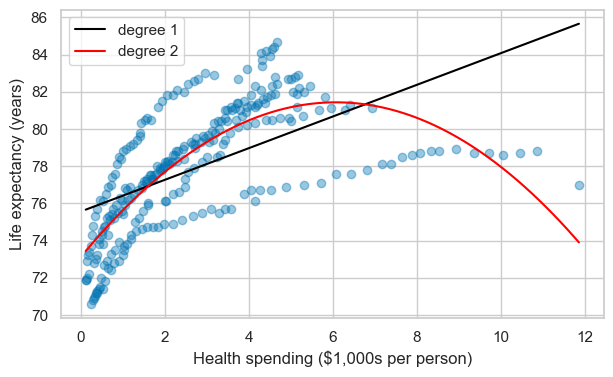

In [160]:
# A "grid" = 200 evenly spaced spending values, so the fitted curves draw smoothly
grid = pd.DataFrame({"spend_k": np.linspace(health["spend_k"].min(), health["spend_k"].max(), 200)})
grid["spend_k_sq"] = grid["spend_k"] ** 2   # the degree-2 model needs x² too

# Data as dots
plt.scatter(health["spend_k"], health["Life_Expectancy"], alpha=0.4)

# Each model's predictions across the grid, drawn as a line
plt.plot(grid["spend_k"], deg1.predict(grid[["spend_k"]]), label="degree 1", color="black")
plt.plot(grid["spend_k"], deg2.predict(grid[["spend_k", "spend_k_sq"]]), label="degree 2", color="red")

# Labels + legend
plt.xlabel("Health spending ($1,000s per person)")
plt.ylabel("Life expectancy (years)")
plt.legend()
plt.show()
# degree 2 even bends DOWN on the far right — that's the USA (spends the most, lives shorter) pulling the curve

Making every power by hand gets old. `PolynomialFeatures` does it for us:

In [161]:
# PolynomialFeatures builds the powers of x for us
from sklearn.preprocessing import PolynomialFeatures

# Set it up for degree 3 -> it will create x, x², x³
poly3 = PolynomialFeatures(degree=3, include_bias=False)   # include_bias=False: LinearRegression adds its own intercept

# Try it on three tiny x values to see what it outputs
poly3.fit_transform(pd.DataFrame({"spend_k": [1, 2, 3]}))  # each row → [x, x², x³]

array([[ 1.,  1.,  1.],
       [ 2.,  4.,  8.],
       [ 3.,  9., 27.]])

### Your Turn
`horsepower` vs `mpg` is curved. Using `cars_train` / `cars_test` from Part 3, add `hp_sq` = horsepower² to both, then fit degree-1 (`horsepower`) and degree-2 (`horsepower` + `hp_sq`) models for `mpg` and compare test MSE.

In [162]:
cars_train = cars_train.copy()
cars_test = cars_test.copy()
cars_train["hp_sq"] = cars_train["horsepower"] ** 2
cars_test["hp_sq"] = cars_test["horsepower"] ** 2

hp_deg1 = LinearRegression().fit(cars_train[["horsepower"]], cars_train["mpg"])
hp_deg2 = LinearRegression().fit(cars_train[["horsepower", "hp_sq"]], cars_train["mpg"])
mse_hp1 = mean_squared_error(cars_test["mpg"], hp_deg1.predict(cars_test[["horsepower"]]))
mse_hp2 = mean_squared_error(cars_test["mpg"], hp_deg2.predict(cars_test[["horsepower", "hp_sq"]]))
print(f"degree 1: {mse_hp1:.2f} | degree 2: {mse_hp2:.2f}")

degree 1: 22.15 | degree 2: 18.42


In [163]:
# Check: run me
assert mse_hp2 < mse_hp1 - 2, "degree 2 should beat degree 1 by a clear margin"
print("Check passed")

Check passed


### 4C. Overfitting
Tiny training set on purpose (30 rows) so overfitting shows up fast. Everything else is the **validation** set — we use it to pick the degree and never touch a test set.

In [164]:
# Keep only 30 rows for training; every other row becomes the validation set
h_train, h_val = train_test_split(health, train_size=30, random_state=1)
print(len(h_train), "train |", len(h_val), "validation")

30 train | 244 validation


In [165]:
# Degrees to try (1 through 8), and empty lists to collect the scores
degrees = range(1, 9)
train_mse, val_mse = [], []

# For each degree: build features -> fit -> score on train AND validation
for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_tr = poly.fit_transform(h_train[["spend_k"]])   # fit_transform on TRAIN
    X_va = poly.transform(h_val[["spend_k"]])         # just transform on VALIDATION
    model = LinearRegression().fit(X_tr, h_train["Life_Expectancy"])
    train_mse.append(mean_squared_error(h_train["Life_Expectancy"], model.predict(X_tr)))
    val_mse.append(mean_squared_error(h_val["Life_Expectancy"], model.predict(X_va)))

# Put the results in a table: one row per degree
pd.DataFrame({"degree": degrees, "train_mse": train_mse, "val_mse": val_mse}).round(2)

/Users/ajay/Library/r-miniconda-arm64/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ajay/Library/r-miniconda-arm64/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ajay/Library/r-miniconda-arm64/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ajay/Library/r-miniconda-arm64/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ajay/Library/r-miniconda-arm64/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ajay/Library/r-miniconda-arm64/lib/python3.10/

,degree,train_mse,val_mse
0,1,5.88,7.30
1,2,2.86,4.11
2,3,2.86,4.09
3,4,2.85,4.04
4,5,2.69,6.94
5,6,2.65,7.86
6,7,2.54,1419.57
7,8,2.54,4349.27


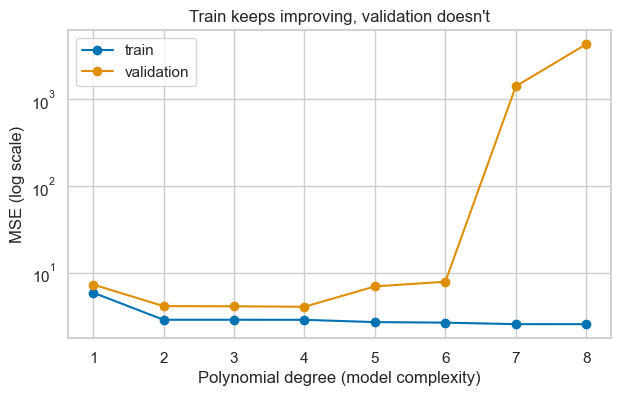

In [166]:
# One line for train error, one for validation error, across degrees
plt.plot(degrees, train_mse, marker="o", label="train")
plt.plot(degrees, val_mse, marker="o", label="validation")

plt.yscale("log")   # validation error explodes — log scale keeps both lines readable

# Labels + legend
plt.xlabel("Polynomial degree (model complexity)")
plt.ylabel("MSE (log scale)")
plt.title("Train keeps improving, validation doesn't")
plt.legend()
plt.show()

/Users/ajay/Library/r-miniconda-arm64/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ajay/Library/r-miniconda-arm64/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ajay/Library/r-miniconda-arm64/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


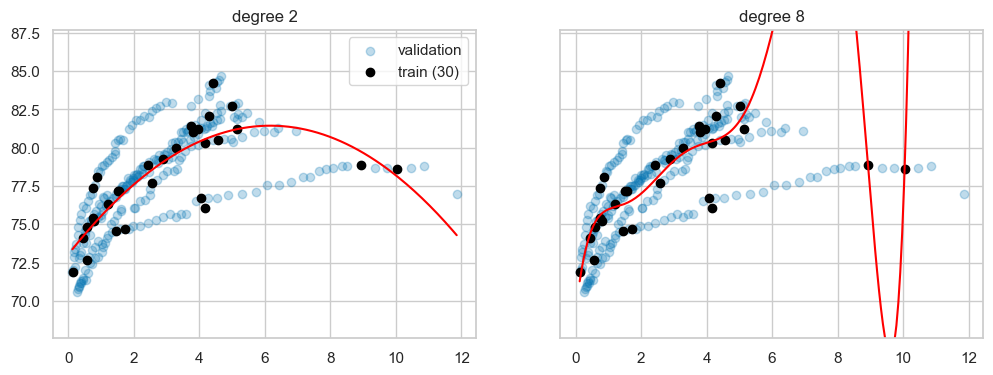

In [167]:
# what the overfit model actually looks like
# Two side-by-side plots that share the same y-axis
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Left plot = degree 2, right plot = degree 8
for ax, d in zip(axes, [2, 8]):
    # Fit a model of degree d on the 30 training rows
    poly = PolynomialFeatures(degree=d, include_bias=False)
    model = LinearRegression().fit(poly.fit_transform(h_train[["spend_k"]]), h_train["Life_Expectancy"])

    # Validation points (faint) and training points (black)
    ax.scatter(h_val["spend_k"], h_val["Life_Expectancy"], alpha=0.25, label="validation")
    ax.scatter(h_train["spend_k"], h_train["Life_Expectancy"], color="black", label="train (30)")

    # The fitted curve across the grid from 4B
    ax.plot(grid["spend_k"], model.predict(poly.transform(grid[["spend_k"]])), color="red")

    # Title, and fix the y-range so the wild degree-8 curve doesn't squash the plot
    ax.set_title(f"degree {d}")
    ax.set_ylim(health["Life_Expectancy"].min() - 3, health["Life_Expectancy"].max() + 3)

axes[0].legend()
plt.show()

---
## Part 5: Logistic Regression
Demo target: is a ride an **airport ride** (1) or not (0), predicted from `distance`?

In [168]:
# Load the classification tools:
#   LogisticRegression -> the classifier
#   confusion_matrix / ConfusionMatrixDisplay -> count and draw TN, FP, FN, TP
#   accuracy_score / precision_score / recall_score -> the three metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score

In [169]:
# True if the pickup OR dropoff zone name contains "Airport" (| means OR)
is_airport = taxis_clean["pickup_zone"].str.contains("Airport") | taxis_clean["dropoff_zone"].str.contains("Airport")

# Store it as a 0/1 column -> this is our target y
taxis_clean["airport"] = is_airport.astype(int)   # True/False → 1/0

# What fraction of rides are 0 vs 1?
taxis_clean["airport"].value_counts(normalize=True).round(3)   # only ~6% are airport rides — remember this

airport
0    0.937
1    0.063
Name: proportion, dtype: float64

### 5A. Fit and predict

In [170]:
# Train/test split (same idea as Part 3)
air_train, air_test = train_test_split(taxis_clean, test_size=0.2, random_state=42)

# Create + fit: X = distance (DataFrame), y = the 0/1 airport column
log_reg = LogisticRegression()
log_reg.fit(air_train[["distance"]], air_train["airport"])

# The fitted parameters, same attribute names as LinearRegression
print("theta0:", log_reg.intercept_.round(3), "| theta1:", log_reg.coef_.round(3))

theta0: [-4.955] | theta1: [[0.379]]


/Users/ajay/Library/r-miniconda-arm64/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ajay/Library/r-miniconda-arm64/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ajay/Library/r-miniconda-arm64/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights


In [171]:
# A few made-up rides at different distances
sample_trips = pd.DataFrame({"distance": [1, 5, 10, 15, 20]})

# predict_proba -> one row per ride, two columns of probabilities (each row adds up to 1)
log_reg.predict_proba(sample_trips).round(3)   # column 0 = P(not airport), column 1 = P(airport)

array([[0.99 , 0.01 ],
       [0.955, 0.045],
       [0.762, 0.238],
       [0.325, 0.675],
       [0.068, 0.932]])

In [172]:
# predict -> turns each probability into a 0/1 label
log_reg.predict(sample_trips)   # label = 1 if P(airport) ≥ 0.5

array([0, 0, 0, 1, 1])

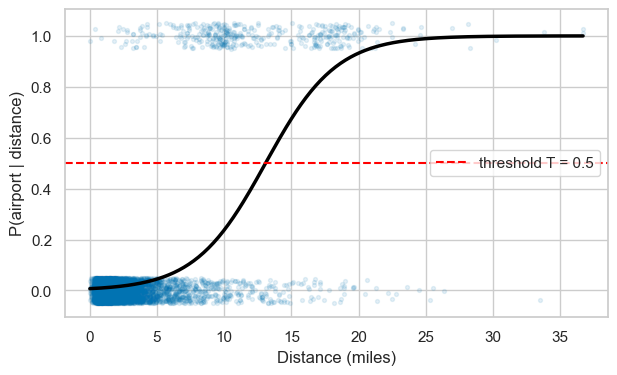

In [173]:
# Small random noise so the 0s and 1s don't sit on one exact line (jitter from Part 2)
y_jitter = np.random.uniform(-0.05, 0.05, len(taxis_clean))

# 300 evenly spaced distances, so the S-curve draws smoothly
dist_grid = pd.DataFrame({"distance": np.linspace(0, taxis_clean["distance"].max(), 300)})

# Actual rides (jittered 0s and 1s)
plt.scatter(taxis_clean["distance"], taxis_clean["airport"] + y_jitter, alpha=0.1, s=8)

# The model's P(airport) across the grid; [:, 1] keeps just the "airport" column
plt.plot(dist_grid["distance"], log_reg.predict_proba(dist_grid)[:, 1], color="black", linewidth=2.5)

# The 0.5 threshold: above the line -> predict 1
plt.axhline(0.5, color="red", linestyle="--", label="threshold T = 0.5")

# Labels + legend
plt.xlabel("Distance (miles)")
plt.ylabel("P(airport | distance)")
plt.legend()
plt.show()

In [174]:
# P(airport) for every test ride ([:, 1] keeps only the "airport" column)
air_probs = log_reg.predict_proba(air_test[["distance"]])[:, 1]

# Apply the threshold ourselves: True/False -> 1/0 (same result as .predict())
air_preds = (air_probs >= 0.5).astype(int)

### 5B. Confusion matrix & metrics

In [175]:
# Compare actual labels vs predicted labels -> a 2x2 table of counts
cm = confusion_matrix(air_test["airport"], air_preds)
cm   # rows = actual [0, 1], columns = predicted [0, 1]

array([[1176,   10],
       [  57,   34]])

In [176]:
# .ravel() flattens the 2x2 table into 4 numbers, in this order: TN, FP, FN, TP
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

TN=1176  FP=10  FN=57  TP=34


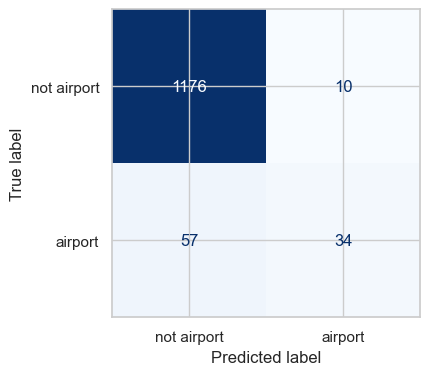

In [177]:
# Same table, drawn as a labeled picture
ConfusionMatrixDisplay(cm, display_labels=["not airport", "airport"]).plot(cmap="Blues", colorbar=False)
plt.show()

In [178]:
# The three metrics by hand, straight from the four counts
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
print(f"accuracy {accuracy:.3f} | precision {precision:.3f} | recall {recall:.3f}")

accuracy 0.948 | precision 0.773 | recall 0.374


In [179]:
# A fake "model": predict 0 (not airport) for every test ride
always_no = np.zeros(len(air_test), dtype=int)

# How accurate is it?
accuracy_score(air_test["airport"], always_no)

0.9287392325763508

A model that *never* says "airport" is almost as accurate as ours. With a rare class, accuracy hides the misses — recall shows them.

In [180]:
# Re-label the same test probabilities with different thresholds and re-score each time
for threshold in [0.5, 0.3, 0.1]:   # lower threshold → more rides called "airport"
    preds_t = (air_probs >= threshold).astype(int)
    print(f"T={threshold}: precision {precision_score(air_test['airport'], preds_t):.3f} | recall {recall_score(air_test['airport'], preds_t):.3f}")

T=0.5: precision 0.773 | recall 0.374
T=0.3: precision 0.754 | recall 0.473
T=0.1: precision 0.605 | recall 0.857


### Your Turn
Predict whether a car is **American** (`origin == "usa"` → 1) from `displacement` (engine size).
1. Make the `usa` column (0/1), split (`test_size=0.2`, `random_state=42`), and fit `LogisticRegression`.
2. Confusion matrix → TN/FP/FN/TP → accuracy, precision, recall **by hand**.
3. Compare to a model that always predicts the majority class.

In [181]:
cars["usa"] = (cars["origin"] == "usa").astype(int)
usa_train, usa_test = train_test_split(cars, test_size=0.2, random_state=42)
log_reg_cars = LogisticRegression().fit(usa_train[["displacement"]], usa_train["usa"])

In [182]:
usa_preds = log_reg_cars.predict(usa_test[["displacement"]])
cm_cars = confusion_matrix(usa_test["usa"], usa_preds)
tn_c, fp_c, fn_c, tp_c = cm_cars.ravel()
accuracy_cars = (tp_c + tn_c) / (tp_c + tn_c + fp_c + fn_c)
precision_cars = tp_c / (tp_c + fp_c)
recall_cars = tp_c / (tp_c + fn_c)
print(f"accuracy {accuracy_cars:.3f} | precision {precision_cars:.3f} | recall {recall_cars:.3f}")

accuracy 0.886 | precision 0.905 | recall 0.884


In [183]:
# majority-class baseline
majority = usa_train["usa"].mode()[0]   # most common class in TRAIN (1 = usa)
always_majority = np.full(len(usa_test), majority)
print("majority class:", majority)
print(f"baseline accuracy {accuracy_score(usa_test['usa'], always_majority):.3f} | model accuracy {accuracy_cars:.3f}")

majority class: 1
baseline accuracy 0.544 | model accuracy 0.886


In [184]:
# Check: run me
assert np.isclose(accuracy_cars, accuracy_score(usa_test["usa"], usa_preds)), "hand accuracy doesn't match sklearn"
assert np.isclose(precision_cars, precision_score(usa_test["usa"], usa_preds)), "hand precision doesn't match sklearn"
assert np.isclose(recall_cars, recall_score(usa_test["usa"], usa_preds)), "hand recall doesn't match sklearn"
print("Check passed")

Check passed


---
## Homework
A few cells that pull the whole week together on `cars`. Run the notebook above first — these reuse `cars` (cleaned, with `year` and `brand`) and `cars_train` / `cars_test`.

**HW 1: Visualizations.** Make one figure with four panels (`plt.subplots(2, 2, figsize=(12, 8))`), each titled and labeled:
a bar chart of the top 10 brands (sorted), a histogram of `mpg`, a scatter of `weight` vs `mpg` with transparency, and a line plot of average `mpg` per `year` with one line per `origin`.

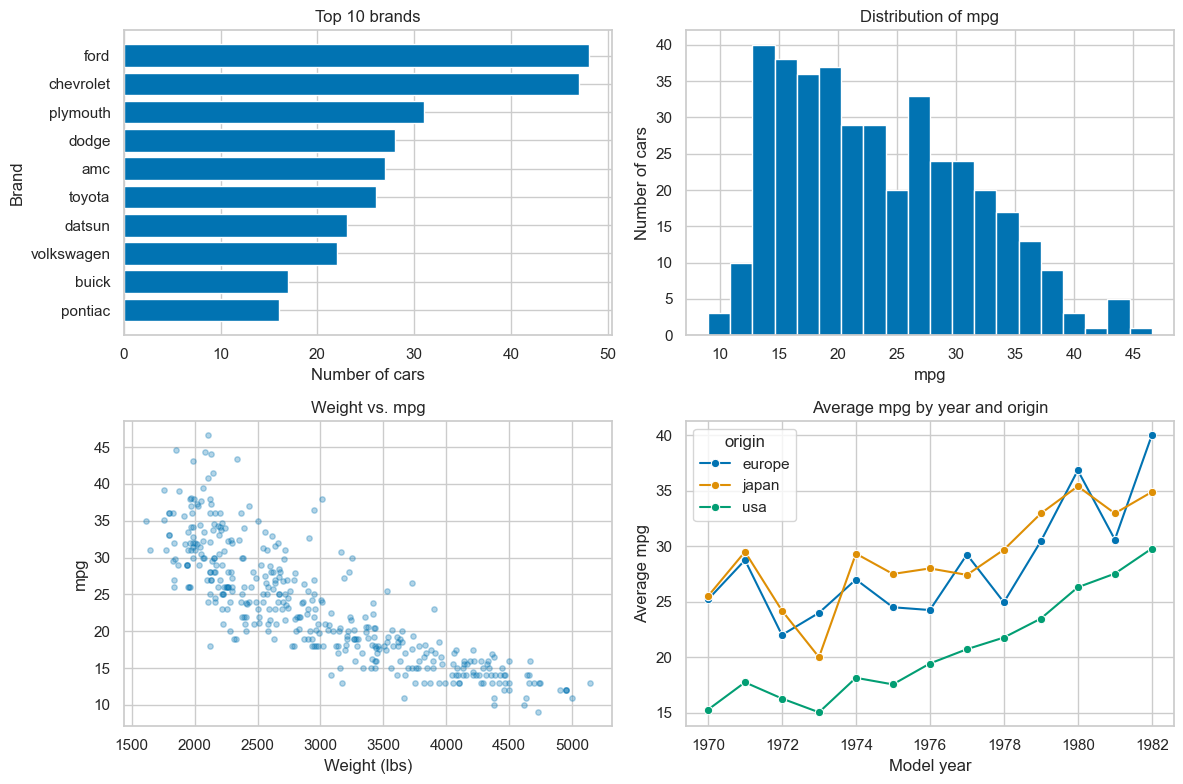

In [185]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top 10 brands (ascending so barh puts the biggest on top)
top_brands = cars["brand"].value_counts().head(10).sort_values()
axes[0, 0].barh(top_brands.index, top_brands.values)
axes[0, 0].set_title("Top 10 brands")
axes[0, 0].set_xlabel("Number of cars")
axes[0, 0].set_ylabel("Brand")

# Histogram of mpg
axes[0, 1].hist(cars["mpg"], bins=20)
axes[0, 1].set_title("Distribution of mpg")
axes[0, 1].set_xlabel("mpg")
axes[0, 1].set_ylabel("Number of cars")

# Weight vs mpg with transparency
axes[1, 0].scatter(cars["weight"], cars["mpg"], alpha=0.3, s=15)
axes[1, 0].set_title("Weight vs. mpg")
axes[1, 0].set_xlabel("Weight (lbs)")
axes[1, 0].set_ylabel("mpg")

# Average mpg per year, one line per origin
mpg_year_origin = cars.groupby(["year", "origin"])["mpg"].mean().reset_index()
sns.lineplot(data=mpg_year_origin, x="year", y="mpg", hue="origin", marker="o", ax=axes[1, 1])
axes[1, 1].set_title("Average mpg by year and origin")
axes[1, 1].set_xlabel("Model year")
axes[1, 1].set_ylabel("Average mpg")

plt.tight_layout()
plt.show()

**HW 2: Model comparison.** Fill in one table comparing test MSE for every `mpg` model this week, plus one new one: your Part 3 OLS features **plus** a one-hot encoded `origin` (drop the reference level). Use the same `cars_train` / `cars_test`.

In [186]:
origin_ohe = pd.get_dummies(cars["origin"], prefix="origin", drop_first=True, dtype=int)   # one-hot origin for ALL of cars; europe is the reference level
X_train_ohe = pd.concat([cars_train[features_cars], origin_ohe.loc[cars_train.index]], axis=1)
X_test_ohe = pd.concat([cars_test[features_cars], origin_ohe.loc[cars_test.index]], axis=1)
ols_ohe_cars = LinearRegression().fit(X_train_ohe, cars_train["mpg"])
mse_ohe_cars = mean_squared_error(cars_test["mpg"], ols_ohe_cars.predict(X_test_ohe))

pd.DataFrame({
    "model": ["constant", "SLR (weight)", "OLS (weight, hp, year)", "OLS + origin", "degree 2 (hp)"],
    "test_mse": [mse_const_cars, mse_slr_cars, mse_ols_cars, mse_ohe_cars, mse_hp2],
}).round(2)

,model,test_mse
0,constant,51.62
1,SLR (weight),17.69
2,"OLS (weight, hp, year)",10.60
3,OLS + origin,11.19
4,degree 2 (hp),18.42


**HW 3: Thresholds.** For your `usa` model, print precision and recall at thresholds 0.3, 0.5, and 0.7 (use `predict_proba`, like the end of the Part 5 demo).

In [187]:
usa_probs = log_reg_cars.predict_proba(usa_test[["displacement"]])[:, 1]
for threshold in [0.3, 0.5, 0.7]:
    preds_t = (usa_probs >= threshold).astype(int)
    print(f"T={threshold}: precision {precision_score(usa_test['usa'], preds_t):.3f} | recall {recall_score(usa_test['usa'], preds_t):.3f}")

T=0.3: precision 0.741 | recall 0.930
T=0.5: precision 0.905 | recall 0.884
T=0.7: precision 0.943 | recall 0.767


**HW 4: Short answers.** One or two sentences each.

1. In 1B, why was dropping the rows with a missing pickup borough a worse choice than filling them with `"Unknown"`, even though under 1% of rows were missing?
2. From the HW 2 table: did adding `origin` lower the test MSE? Why might a feature add little once correlated features are already in the model?
3. Why would a model that predicts `fare` using `total` as a feature look great on paper but be useless in practice?
4. In 4C, what happened to train MSE vs. validation MSE as the degree went up, and which degree would you pick?
5. For the airport model, the always-"no" baseline was ~93% accurate. For the `usa` model, how did your model compare to its baseline, and why is the gap so different?

*Answers:*

1. Missingness wasn't random: rides with no pickup borough averaged about $25.88 vs. $13.04 for the rest, so dropping them quietly removed the most expensive rides and biased fare downward. Filling with `"Unknown"` keeps every row and lets a model learn that those rides are different.
2. No. Test MSE went from 10.60 to 11.19. Origin is strongly correlated with weight and horsepower (American cars are heavier and more powerful), so once those are in the model, origin adds almost no new information and mostly adds noise.
3. `total` is fare plus tip, tolls and tax, so it almost contains the answer (correlation 0.97). That's leakage: you only know `total` after the ride ends, when you'd already know the fare, so the model can't be used for real predictions.
4. Train MSE mostly kept falling (2.86 at degree 2 to about 2.7–2.8 at degrees 5–6), but validation MSE bottomed out around degrees 2–4 and then shot up (19.6 at degree 6, 739 at degree 8). I'd pick degree 2: it's about as good as degrees 3–4 on validation and it's the simplest.
5. The `usa` model got 0.886 accuracy vs. 0.544 for always predicting "usa", a gap of about 34 points. The airport model beat its ~93% baseline by only ~2 points. The classes in `usa` are close to balanced, so the baseline is weak and accuracy is a meaningful metric. Airport rides are rare (~6%), so predicting "no" every time already looks very accurate.